In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data load

In [3]:
embs = pd.read_parquet("../../data/playlist/embeddings_pure_bolt.parquet")
tracks = pd.read_parquet("../../data/playlist/track_lookup.parquet")
df = tracks.merge(embs, on="track_rowid", how="inner")
del embs, tracks

df

,track_rowid,track_name,track_popularity,id_isrc,artist_rowid,artist_name,album_rowid,album_name,label,release_date,...,e118,e119,e120,e121,e122,e123,e124,e125,e126,e127
0,1,The Giver,89,USUG12501598,466102,Chappell Roan,1,The Giver,Chappell Roan PS/ Island,2025-03-13,...,-0.208362,0.368888,0.248498,-0.293111,0.092885,-0.273926,0.206350,0.074494,-0.144147,0.180991
1,2,Another Life,43,SEUM72401960,1853555,NOTD,2,Digital Notes,Universal Music AB,2025-03-14,...,-0.196914,0.312557,0.266789,0.099505,0.058830,-0.240161,0.055187,0.055483,0.083572,-0.155353
2,3,Lover Online,43,SEUM72401353,1853555,NOTD,2,Digital Notes,Universal Music AB,2025-03-14,...,-0.041046,0.378840,0.212466,0.201121,-0.047752,-0.092247,0.042131,-0.049926,0.082891,-0.183175
3,4,Crash,56,SEUM72500201,1853555,NOTD,2,Digital Notes,Universal Music AB,2025-03-14,...,-0.108012,0.492578,0.206480,0.147059,-0.185124,-0.239156,0.158749,0.039845,0.067549,-0.325725
4,5,I Just Missed A Call,51,SEUM72500202,1853555,NOTD,2,Digital Notes,Universal Music AB,2025-03-14,...,-0.094603,0.617007,0.441123,0.130798,-0.037468,-0.288760,0.070787,-0.015783,0.116695,-0.321839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5412044,247827222,Pequena Eva,0,QZTPX2525455,5984151,Gabby B,56516896,Pequena Eva,Muy Bueno,2025-11-07,...,-0.282249,0.222295,0.199448,-0.269301,-0.100577,-0.182650,-0.174116,0.071979,-0.239299,-0.272316
5412045,247831685,Reinaldo,0,BK4DA2552416,2883735,Allana Macedo,56517730,Reinaldo,AM PRODUCOES,2025-11-07,...,-0.286069,0.146482,0.188149,-0.256369,-0.164195,-0.112468,-0.185224,0.183731,-0.202297,-0.292355
5412046,248136901,APRCOYE,0,QZXYG2505818,7109412,Anyoca,56588089,APRCOYE,Kasterwey Music,2025-11-06,...,0.161273,0.200828,0.250193,-0.311748,-0.056369,0.208626,-0.204549,0.002240,-0.233303,0.177959
5412047,248198486,Más allá,0,QZZ8B2544011,4892969,Alcover,56603782,Más allá,"WE LOUD ENTERTAINMENT, LLC",2025-11-07,...,0.089543,0.252793,0.217592,-0.183756,0.267667,0.173088,-0.197474,0.112230,-0.179609,-0.021674


In [4]:
emb_cols = [c for c in df.columns if c.startswith("e")]
track_cols = [c for c in df.columns if c not in emb_cols]

# Full scale dataset

### Finding - embeddings moduli and distances are roughly normally distributed

In [4]:
moduli = (df.sample(n = 100_000)[emb_cols] ** 2).sum(axis=1)
moduli.describe()

count    100000.000000
mean          9.399098
std           2.569257
min           2.664703
25%           7.639095
50%           9.023041
75%          10.716175
max          54.444012
dtype: float64

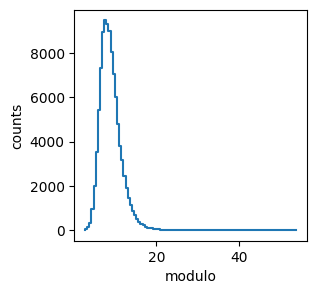

In [35]:
counts, bins = np.histogram(moduli, bins=100)
plt.figure(figsize=(3,3)); plt.step(bins[:-1], counts); plt.xlabel("modulo"); plt.ylabel("counts"); plt.show()

In [39]:
distances = (((_xs := df.sample(n = 20_000)[emb_cols]).iloc[:10_000] - _xs.iloc[10_000])  ** 2).sum(axis=1)
distances.describe()

count    10000.000000
mean        14.300953
std          3.021507
min          3.234028
25%         12.227218
50%         14.082354
75%         16.070083
max         36.652351
dtype: float64

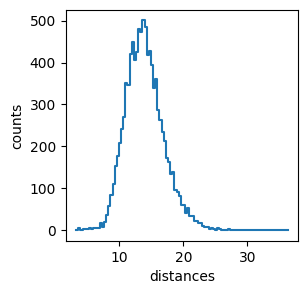

In [40]:
counts, bins = np.histogram(distances, bins=100)
plt.figure(figsize=(3,3)); plt.step(bins[:-1], counts); plt.xlabel("distances"); plt.ylabel("counts"); plt.show()

# Filtered dataset

For the next operations the dataset is too large for working on my home pc. We filter it.

In [5]:
df = df[df["track_popularity"] > 30].reset_index(drop=True)
df

,track_rowid,track_name,track_popularity,id_isrc,artist_rowid,artist_name,album_rowid,album_name,label,release_date,...,e118,e119,e120,e121,e122,e123,e124,e125,e126,e127
0,1,The Giver,89,USUG12501598,466102,Chappell Roan,1,The Giver,Chappell Roan PS/ Island,2025-03-13,...,-0.208362,0.368888,0.248498,-0.293111,0.092885,-0.273926,0.206350,0.074494,-0.144147,0.180991
1,2,Another Life,43,SEUM72401960,1853555,NOTD,2,Digital Notes,Universal Music AB,2025-03-14,...,-0.196914,0.312557,0.266789,0.099505,0.058830,-0.240161,0.055187,0.055483,0.083572,-0.155353
2,3,Lover Online,43,SEUM72401353,1853555,NOTD,2,Digital Notes,Universal Music AB,2025-03-14,...,-0.041046,0.378840,0.212466,0.201121,-0.047752,-0.092247,0.042131,-0.049926,0.082891,-0.183175
3,4,Crash,56,SEUM72500201,1853555,NOTD,2,Digital Notes,Universal Music AB,2025-03-14,...,-0.108012,0.492578,0.206480,0.147059,-0.185124,-0.239156,0.158749,0.039845,0.067549,-0.325725
4,5,I Just Missed A Call,51,SEUM72500202,1853555,NOTD,2,Digital Notes,Universal Music AB,2025-03-14,...,-0.094603,0.617007,0.441123,0.130798,-0.037468,-0.288760,0.070787,-0.015783,0.116695,-0.321839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1478086,235991741,Senta Poca,32,QZYFZ2520393,2462451,Kadu Martins,54021378,Senta Poca,JNK Records,2025-10-21,...,-0.331078,0.271996,0.192200,-0.313651,-0.070902,-0.141083,-0.193133,-0.184256,-0.212529,-0.329982
1478087,236065089,Desatento,31,ILTON2510711,326629,Mari & Rayane,54037004,É Na Pegada Darminina - Pt.2,Mari & Rayane,2025-10-17,...,-0.251974,0.194054,0.189883,-0.267390,-0.059279,-0.142265,-0.177896,0.083075,-0.229462,-0.231571
1478088,239230939,Por Quê - Ao Vivo,31,BKOKK2500170,6787302,Natanzinho Lima,54670851,De Bar em Bar 8 (Ao Vivo),Natanzinho Lima,2025-10-24,...,-0.261020,0.200717,0.191363,-0.274765,-0.092903,-0.146083,-0.187004,0.144065,-0.235213,-0.261142
1478089,240713106,February 3rd,39,TCAJX2598647,9220217,Iggoor,54995254,February 3rd,CWX Records,2025-08-14,...,-0.333963,0.178671,0.224742,-0.271873,-0.165313,-0.058321,-0.270387,0.071844,-0.228393,-0.237355


# Similiarities

In [6]:
import torch

# --- track tensors
lookup = df[track_cols]
embs = torch.tensor(df[emb_cols].to_numpy())
norm_embs = embs / embs.norm(dim=1, keepdim=True)
emb_norms_sq = embs.pow(2).sum(dim=1)   # precomputed once for L2 expanded formula

# --- artist tensors (deduplicated, one row per artist) ---
_artist_embs_mean = df.groupby("artist_rowid")[emb_cols].mean()
_artist_info = df.groupby("artist_rowid").agg(
    artist_name=("artist_name", "first"),
    max_popularity=("track_popularity", "max"),
)
_artist_full = _artist_info.join(_artist_embs_mean).reset_index()
_ae = torch.tensor(_artist_full[emb_cols].to_numpy())
artist_embs = _ae
norm_artist_embs = _ae / _ae.norm(dim=1, keepdim=True)
artist_emb_norms_sq = _ae.pow(2).sum(dim=1)
artist_meta = _artist_full[["artist_rowid", "artist_name", "max_popularity"]]

# --- album tensors (deduplicated, one row per album) ---
_album_embs_mean = df.groupby("album_rowid")[emb_cols].mean()
_album_info = df.groupby("album_rowid").agg(
    album_name=("album_name", "first"),
    artist_name=("artist_name", "first"),
    max_popularity=("track_popularity", "max"),
)
_album_full = _album_info.join(_album_embs_mean).reset_index()
_abe = torch.tensor(_album_full[emb_cols].to_numpy())
album_embs = _abe
norm_album_embs = _abe / _abe.norm(dim=1, keepdim=True)
album_emb_norms_sq = _abe.pow(2).sum(dim=1)
album_meta = _album_full[["album_rowid", "album_name", "artist_name", "max_popularity"]]

# --- label tensors (grouped by name string — no rowid available) ---
_LABEL_MIN_TRACKS = 20
_label_embs_mean = df.groupby("label")[emb_cols].mean()
_label_info = df.groupby("label").agg(
    max_popularity=("track_popularity", "max"),
    track_count=("track_rowid", "count"),
)
_label_full = _label_info.join(_label_embs_mean).reset_index()
_label_full = _label_full[_label_full["track_count"] >= _LABEL_MIN_TRACKS].reset_index(drop=True)
_le = torch.tensor(_label_full[emb_cols].to_numpy())
label_embs = _le
norm_label_embs = _le / _le.norm(dim=1, keepdim=True)
label_emb_norms_sq = _le.pow(2).sum(dim=1)
label_meta = _label_full[["label", "max_popularity", "track_count"]]

print(f"Tracks : {len(lookup):,}")
print(f"Artists : {len(artist_meta):,}")
print(f"Albums  : {len(album_meta):,}")
print(f"Labels  : {len(label_meta):,}  (>= {_LABEL_MIN_TRACKS} tracks)")


# --- core functions ---

def _similar_cosine(query_vec, norm_table, meta, k, diverse, diverse_col, opposite):
    """query_vec and norm_table rows must be pre-normalized."""
    fetch = k * 50 + 1
    sims = query_vec @ norm_table.T
    top_vals, top_idx = torch.topk(sims, min(fetch, len(sims)), largest=not opposite)
    candidates = meta.iloc[top_idx.tolist()].copy()
    candidates["similarity"] = top_vals.numpy()
    if diverse and diverse_col:
        candidates = candidates.drop_duplicates(subset=diverse_col)
    return candidates.head(k)


def _similar_l2(query_vec, emb_table, norms_sq, meta, k, diverse, diverse_col, opposite):
    """‖u−v‖² = ‖u‖² + ‖v‖² − 2(u·v) — same matmul as cosine, no (N, D) intermediate."""
    query_norm_sq = query_vec.pow(2).sum()
    fetch = k * 50 + 1
    sims = query_norm_sq + norms_sq - 2 * (query_vec @ emb_table.T)
    top_vals, top_idx = torch.topk(sims, min(fetch, len(sims)), largest=opposite)
    candidates = meta.iloc[top_idx.tolist()].copy()
    candidates["similarity"] = top_vals.numpy()
    if diverse and diverse_col:
        candidates = candidates.drop_duplicates(subset=diverse_col)
    return candidates.head(k)

# --- resolvers — return (norm_vec, raw_vec, label, idx) ---

def _resolve_track(query, artist=None):
    matches = lookup[lookup["track_name"].str.contains(query, case=False, na=False)]
    if artist is not None:
        matches = matches[matches["artist_name"].str.contains(artist, case=False, na=False)]
    if matches.empty:
        desc = f"'{query}'" + (f" by '{artist}'" if artist else "")
        raise ValueError(f"No tracks matching {desc}")
    row = matches.sort_values("track_popularity", ascending=False).iloc[0]
    tid = row.name
    label = f"{row['track_name']} — {row['artist_name']}  (pop {row['track_popularity']})"
    return norm_embs[tid], embs[tid], label, int(tid)


def _resolve_artist(query):
    matches = artist_meta[artist_meta["artist_name"].str.contains(query, case=False, na=False)]
    if matches.empty:
        raise ValueError(f"No artists matching '{query}'")
    row = matches.sort_values("max_popularity", ascending=False).iloc[0]
    aid = row.name
    return norm_artist_embs[aid], artist_embs[aid], row["artist_name"], int(aid)


def _resolve_album(query, artist=None):
    matches = album_meta[album_meta["album_name"].str.contains(query, case=False, na=False)]
    if artist is not None:
        matches = matches[matches["artist_name"].str.contains(artist, case=False, na=False)]
    if matches.empty:
        desc = f"'{query}'" + (f" by '{artist}'" if artist else "")
        raise ValueError(f"No albums matching {desc}")
    row = matches.sort_values("max_popularity", ascending=False).iloc[0]
    lid = row.name
    return norm_album_embs[lid], album_embs[lid], f"{row['album_name']} — {row['artist_name']}", int(lid)


def _resolve_label(query):
    matches = label_meta[label_meta["label"].str.contains(query, case=False, na=False)]
    if matches.empty:
        raise ValueError(f"No labels matching '{query}'")
    row = matches.sort_values("max_popularity", ascending=False).iloc[0]
    lid = row.name
    return norm_label_embs[lid], label_embs[lid], row["label"], int(lid)


# --- display column sets ---

_TRACK_COLS = ["track_name", "artist_name", "track_popularity", "similarity"]
_ARTIST_COLS = ["artist_name", "max_popularity", "similarity"]
_ALBUM_COLS  = ["album_name", "artist_name", "max_popularity", "similarity"]
_LABEL_COLS  = ["label", "track_count", "max_popularity", "similarity"]


# --- public interfaces ---

def similar_tracks(query, artist=None, k=10, diverse=True, opposite=False):
    """Track → tracks (cosine similarity)."""
    norm_vec, raw_vec, label, _ = _resolve_track(query, artist)
    print(f"Query: {label}\n")
    display(_similar_cosine(norm_vec, norm_embs, lookup, k, diverse, "artist_name", opposite)[_TRACK_COLS])


def similar_tracks_l2(query, artist=None, k=10, diverse=True, opposite=False):
    """Track → tracks (L2 sim)."""
    norm_vec, raw_vec, label, _ = _resolve_track(query, artist)
    print(f"Query: {label}\n")
    display(_similar_l2(raw_vec, embs, emb_norms_sq, lookup, k, diverse, "artist_name", opposite)[_TRACK_COLS])


def similar_artists(query, k=10, diverse=True, opposite=False):
    """Artist → artists (cosine). diverse deduplicates on artist_name."""
    norm_vec, _, label, _ = _resolve_artist(query)
    print(f"Query artist: {label}")
    display(_similar_cosine(norm_vec, norm_artist_embs, artist_meta, k, diverse, "artist_name", opposite)[_ARTIST_COLS])


def similar_albums(query, artist=None, k=10, diverse=True, opposite=False):
    """Album → albums (cosine). diverse deduplicates on artist_name."""
    norm_vec, _, label, _ = _resolve_album(query, artist)
    print(f"Query album: {label}")
    display(_similar_cosine(norm_vec, norm_album_embs, album_meta, k, diverse, "artist_name", opposite)[_ALBUM_COLS])


def similar_labels(query, k=10, opposite=False):
    """Label → labels (cosine). No diverse — each result is already a unique label."""
    norm_vec, _, label, _ = _resolve_label(query)
    print(f"Query label: {label}")
    display(_similar_cosine(norm_vec, norm_label_embs, label_meta, k, False, None, opposite)[_LABEL_COLS])


def similar_tracks_for_artist(query, k=10, diverse=True, opposite=False):
    """Artist mean embedding → tracks (cosine)."""
    norm_vec, _, label, _ = _resolve_artist(query)
    print(f"Query artist: {label}")
    display(_similar_cosine(norm_vec, norm_embs, lookup, k, diverse, "artist_name", opposite)[_TRACK_COLS])


def similar_tracks_for_album(query, artist=None, k=10, diverse=True, opposite=False):
    """Album mean embedding → tracks (cosine)."""
    norm_vec, _, label, _ = _resolve_album(query, artist)
    print(f"Query album: {label}")
    display(_similar_cosine(norm_vec, norm_embs, lookup, k, diverse, "artist_name", opposite)[_TRACK_COLS])


def similar_tracks_for_label(query, k=10, diverse=True, opposite=False):
    """Label mean embedding → tracks (cosine)."""
    norm_vec, _, label, _ = _resolve_label(query)
    print(f"Query label: {label}")
    display(_similar_cosine(norm_vec, norm_embs, lookup, k, diverse, "artist_name", opposite)[_TRACK_COLS])

Tracks : 1,478,091
Artists : 210,084
Albums  : 819,877
Labels  : 9,717  (>= 20 tracks)


### Finding - l2 and cosine similarity gives similar results

In [7]:
similar_tracks("interzone")
similar_tracks_l2("interzone")

Query: Interzone - 2007 Remaster — Joy Division  (pop 47)



,track_name,artist_name,track_popularity,similarity
30826,Interzone - 2007 Remaster,Joy Division,47,1.000000
1093073,Dreams Never End - 2015 Remaster,New Order,55,0.812171
1070413,Dark Entries,Bauhaus,57,0.801865
797390,Eighties - 2007 Digital Remaster,Killing Joke,56,0.788095
1039494,Hong Kong Garden,Siouxsie and the Banshees,56,0.786941
728346,Mildred Pierce,Sonic Youth,47,0.781600
980283,Life Goes On,The Damned,49,0.768595
1114373,Play for Today - 2006 Remaster,The Cure,50,0.759851
1023231,Another the Letter - 2006 Remastered Version,Wire,36,0.754113
986462,The Fire,The Sound,40,0.751274


Query: Interzone - 2007 Remaster — Joy Division  (pop 47)



,track_name,artist_name,track_popularity,similarity
30826,Interzone - 2007 Remaster,Joy Division,47,0.000000
1093073,Dreams Never End - 2015 Remaster,New Order,55,3.076026
1070413,Dark Entries,Bauhaus,57,3.233704
1039494,Hong Kong Garden,Siouxsie and the Banshees,56,3.478119
797390,Eighties - 2007 Digital Remaster,Killing Joke,56,3.602701
728346,Mildred Pierce,Sonic Youth,47,3.913684
30835,Monkey Gone to Heaven,Pixies,64,4.013089
980283,Life Goes On,The Damned,49,4.064916
1114373,Play for Today - 2006 Remaster,The Cure,50,4.186626
1023439,Things We Never Did,Sad Lovers & Giants,48,4.232812


### Finding - negative similarity is ...eeehmm... more interpretable with cosine 

In [8]:
similar_tracks("dunkelheit", opposite=True)
similar_tracks_l2("dunkelheit", opposite=True)

Query: Dunkelheit — Burzum  (pop 54)



,track_name,artist_name,track_popularity,similarity
819734,Little Mo' Betta,David Davis,32,-0.128778
1371259,"Somehow, Someway",Chad Price,32,-0.127242
676382,Make It Happen,John Splithoff,37,-0.121990
697515,Let Me Love You,N2N,33,-0.120475
1374695,How Will I Know,Guestlist.,32,-0.118643
1202518,C'est la vie,Maurice Moore,34,-0.118067
384736,Smart Love,Drax Project,31,-0.113644
1217043,Drunk Words,Mitchy & André,34,-0.112677
241283,Won't Ever Say Goodbye,The Shadowboxers,31,-0.111649
540267,Sunday Morning,Little Giants,31,-0.111265


Query: Dunkelheit — Burzum  (pop 54)



,track_name,artist_name,track_popularity,similarity
1088487,let's forget what we could be,Celicia Rose,39,87.816170
885562,Chitaury,J Rodis,41,77.562218
1335047,Better Off,Yuki Shinoda,37,72.743080
1222599,Black T,Coco Laced,43,69.133179
1468126,Regret It,Ashwin Gane,41,63.393196
1274650,Winter Ahead (with PARK HYO SHIN),V,79,63.042072
131033,Who,Jimin,84,54.301418
1468990,Espejo,Ana J,38,52.805859
1109192,Electric Wind,Amado la R,46,49.728043
1466713,TAS COMO LOCO - Remix,Alayón,34,45.605629


### Finding - similarity holds on simple mean-derived entities

In [9]:
similar_albums("unknown pleasures")

Query album: Unknown Pleasures (Collector's Edition) — Joy Division


,album_name,artist_name,max_popularity,similarity
7150,Unknown Pleasures (Collector's Edition),Joy Division,67,1.000000
572095,The Sky's Gone Out,Bauhaus,52,0.848742
569292,Movement,New Order,55,0.842240
550903,The Scream,Siouxsie and the Banshees,56,0.820310
518399,From The Lion's Mouth,The Sound,48,0.811206
553292,Faith,The Cure,47,0.805788
392642,Night Time,Killing Joke,56,0.800125
541974,Epic Garden Music,Sad Lovers & Giants,48,0.799063
265674,Only Theatre of Pain,Christian Death,53,0.795445
481877,First and Last and Always,Sisters of Mercy,52,0.794414


In [10]:
similar_albums("amber", "autechre")

Query album: Amber — Autechre


,album_name,artist_name,max_popularity,similarity
32285,Amber,Autechre,37,1.000000
32241,Tomorrow's Harvest,Boards of Canada,43,0.942772
98873,76:14,Global Communication,38,0.927458
33935,Surfing On Sine Waves,Polygon Window,32,0.925474
32228,R Plus Seven,Oneohtrix Point Never,44,0.924574
32306,Sakura,Susumu Yokota,49,0.916444
33938,Stay Down,Two Lone Swordsmen,31,0.915988
96541,Budakhan Mindphone,Squarepusher,37,0.910146
98823,April,Bochum Welt,33,0.909109
579485,Whole Numbers Play the Basics,Casino Versus Japan,39,0.906593


In [11]:
similar_albums("sunbather")

Query album: Sunbather — Deafheaven


,album_name,artist_name,max_popularity,similarity
560328,Sunbather,Deafheaven,49,1.000000
495400,I Want to Be There,Sadness,41,0.802002
728814,Paracletus,Deathspell Omega,35,0.774302
710596,Melting Sun,Lantlôs,33,0.764836
7004,Écailles de lune,Alcest,39,0.764038
598084,Jord,MØL,41,0.758780
608839,Moonlover,Ghost Bath,33,0.748090
582093,Autumn,ColdWorld,31,0.737911
588731,Ashes Against The Grain,Agalloch,40,0.730851
554085,You Won't Get What You Want,Daughters,34,0.727708


In [12]:
similar_artists("electric wizard")

Query artist: Electric Wizard


,artist_name,max_popularity,similarity
71951,Electric Wizard,50,1.000000
79722,Sleep,52,0.935455
87849,Weedeater,42,0.932514
152424,Toke,41,0.922463
137881,Bongzilla,42,0.920350
102959,Belzebong,39,0.919415
171076,Acid King,43,0.916781
189353,Dopelord,40,0.916485
107180,Eyehategod,46,0.916072
56233,Cathedral,38,0.914664


In [13]:
similar_artists("the stooges", k=10)

Query artist: The Stooges


,artist_name,max_popularity,similarity
84028,The Stooges,57,1.000000
76057,MC5,44,0.919779
168340,New York Dolls,52,0.908437
110198,Iggy Pop,72,0.891509
156514,Richard Hell,48,0.881569
118872,The Sonics,54,0.876188
77916,Dead Boys,51,0.868577
129260,Buzzcocks,62,0.860369
146650,Johnny Thunders & The Heartbreakers,45,0.858715
170090,Television,52,0.854735


In [14]:
similar_artists("pharoah sanders", k=10)

Query artist: Pharoah Sanders


,artist_name,max_popularity,similarity
104234,Pharoah Sanders,44,1.000000
141218,Sun Ra & His Arkestra,39,0.934437
159735,Sun Ra,46,0.928911
161632,Alice Coltrane,55,0.912370
176168,Ahmad Jamal Trio,51,0.904746
61100,Gary Bartz,35,0.900519
24273,Max Roach,35,0.894282
118310,Lonnie Liston Smith,47,0.892510
110120,Yusef Lateef,56,0.892321
98129,Donald Byrd,49,0.887174


In [15]:
similar_labels("stones throw")

Query label: Stones Throw Records


,label,track_count,max_popularity,similarity
7773,Stones Throw Records,377,74,1.000000
4660,Lex Records,215,83,0.913148
1377,Brainfeeder,189,72,0.894263
937,BBE Music,36,52,0.881056
1209,Big Dada,90,66,0.874029
1208,Big Crown Records,150,61,0.868136
3940,Innovative Leisure,120,69,0.866626
2939,Fat Beats Records,65,59,0.851644
4074,Jakarta,97,52,0.849075
6371,Polar Entertainment,22,47,0.842341
